# 03 — Random Forest (weekly silver volatility)

Random Forest on the **HAR features plus the EXOG cross-asset RV lags**. This is the
first model that can exploit volatility spillovers across asset classes (gold/silver
vol linkage, VIX as a global risk proxy), and it carries the same EXOG philosophy as
`weekly/04_random_forest.ipynb` on the returns side.

Hyperparameters are tuned on the validation split via a small grid, then the model is
re-fit on train+val. Features come from `volatility_weekly.csv` — run `00_features.ipynb`
first.


## Setup


In [10]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
from vol_utils import vol_evaluate, vol_period_metrics, vol_diebold_mariano, walk_forward
from eval_utils import PERIODS
import warnings; warnings.filterwarnings('ignore')

SEED = 42
plt.rcParams['figure.figsize'] = (10, 4)

frame = pd.read_csv('../../data/processed/volatility_weekly.csv',
                    parse_dates=['Date']).set_index('Date')
train_df = frame[frame['split'] == 'train']
val_df   = frame[frame['split'] == 'val']
test_df  = frame[frame['split'] == 'test']
trval_df = frame[frame['split'] != 'test']

FEATS_HAR  = ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
FEATS_EXOG = [c for c in frame.columns if c.endswith('_rv_lag1') and not c.startswith('silver')]
FEATS_ALL  = FEATS_HAR + FEATS_EXOG
print('features:', FEATS_ALL)

features: ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1', 'gold_rv_lag1', 'copper_rv_lag1', 'usd_rv_lag1', 'sp500_rv_lag1', 'vix_rv_lag1', 'oil_rv_lag1']


## 1. Hyperparameter tuning

Small grid search over tree count / depth / leaf size. Each configuration is fit on the
train split and scored by RMSE on the validation split; the lowest-RMSE configuration
is kept.


In [11]:
y_tr = train_df['target']; y_v = val_df['target']

def tune_rf(X_tr, y_tr, X_v, y_v):
    grid = ParameterGrid({'n_estimators': [200, 400], 'max_depth': [3, 5, None],
                          'min_samples_leaf': [2, 5]})
    best = (np.inf, None)
    for p in grid:
        m = RandomForestRegressor(random_state=SEED, **p).fit(X_tr, y_tr)
        rmse = np.sqrt(mean_squared_error(y_v, m.predict(X_v)))
        if rmse < best[0]:
            best = (rmse, p)
    return best[1]

rf_best = tune_rf(train_df[FEATS_ALL], y_tr, val_df[FEATS_ALL], y_v)
print('RF best params:', rf_best)


RF best params: {'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 200}


## 2. Refit on train+val and evaluate

The best configuration is re-fit on train+val combined, then scored once on the test
set.


In [12]:
y_test    = test_df['target'].values
prev_test = test_df['rv_w_lag1'].values

# Single-fit on train+val with the tuned hyperparameters; keeps a canonical `rf`
# model around for §4 feature-importance interpretation.
rf = RandomForestRegressor(random_state=SEED, **rf_best).fit(trval_df[FEATS_ALL], trval_df['target'])
rf_pred_single = rf.predict(test_df[FEATS_ALL])

# Walk-forward RF: refit every 4 weeks on all data up to t-1 (expanding window),
# frozen hyperparameters from §1. Mirrors the returns chapter's `walk_forward()`
# cadence in `notebooks/weekly/04_random_forest.ipynb` and matches GARCH's
# walk-forward setup in `01_garch`.
def _rf_fit(X, y, params=rf_best):
    return RandomForestRegressor(random_state=SEED, **params).fit(X, y)

rf_pred = walk_forward(frame, test_df.index, FEATS_ALL, fit_fn=_rf_fit, refit_every=4)

results = [vol_evaluate('RF (HAR+EXOG)', y_test, rf_pred, prev_test)]

# Single-fit RMSE for reference.
print(f'\nSingle-fit RF (HAR+EXOG) RMSE (for reference): '
      f'{np.sqrt(((y_test - rf_pred_single)**2).mean()):.5f}    '
      f'walk-forward RMSE: {np.sqrt(((y_test - rf_pred)**2).mean()):.5f}')

RF (HAR+EXOG)                   RMSE=0.03326  MAE=0.01742  R2=+0.238  DCA=0.684

Single-fit RF (HAR+EXOG) RMSE (for reference): 0.03526    walk-forward RMSE: 0.03326


## 3. DM vs the Naïve floor — does RF beat $\text{RV}_{t-1}$?

The chapter's central question: is weekly silver volatility predictable beyond last
week's value? The headline RMSE is now in place, but the RF — unlike HAR — buys its
fit using **EXOG cross-asset RVs** on top of the silver lags, so the relevant test is
whether *this* feature set has lower loss than Naïve $\text{RV}_{t-1}$. Diebold-Mariano
(1995) with Newey-West (1987) lag-1 variance via `vol_diebold_mariano`; negative DM =
RF has lower loss.

**QLIKE is the primary loss.** Weekly silver RV is heavy-tailed enough that under
squared-error loss a handful of extreme weeks dominate the differential and inflate the
DM variance, so an RMSE improvement that is real and steady can still fail an MSE-DM
test. The volatility-forecasting literature (Patton 2011) therefore reports forecasts
under **QLIKE**, a proxy-robust ratio loss; squared-error DM is kept underneath only as
a reference. The same comparison is collected across models in `evaluation.ipynb` §4.


In [13]:
# Diebold-Mariano: RF (HAR+EXOG) vs the Naive RV_{t-1} floor.
print('QLIKE loss  --  primary test:')
vol_diebold_mariano(y_test, rf_pred, prev_test, 'RF (HAR+EXOG)', 'Naive', loss='qlike')

print('\nSquared-error loss  --  reference:')
vol_diebold_mariano(y_test, rf_pred, prev_test, 'RF (HAR+EXOG)', 'Naive', loss='mse');


QLIKE loss  --  primary test:
RF (HAR+EXOG)                vs Naive         [qlike]  DM=-2.424  p=0.015  *     -> winner: RF (HAR+EXOG)

Squared-error loss  --  reference:
RF (HAR+EXOG)                vs Naive         [mse  ]  DM=-1.164  p=0.244  (ns)  -> winner: tie


## 4. Feature importance

Mean decrease in impurity (MDI) across the forest — which features the trees actually
split on. The HAR lags are expected to dominate; the question is whether any EXOG
cross-asset RV earns non-trivial importance, which would be direct evidence of
volatility spillover.


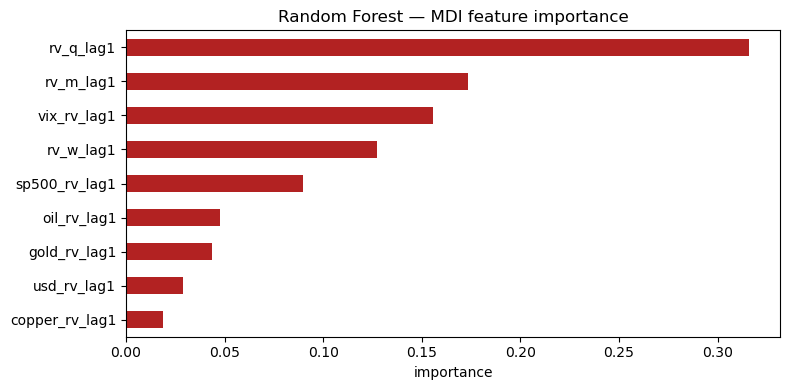

rv_q_lag1         0.3158
rv_m_lag1         0.1733
vix_rv_lag1       0.1558
rv_w_lag1         0.1274
sp500_rv_lag1     0.0895
oil_rv_lag1       0.0474
gold_rv_lag1      0.0435
usd_rv_lag1       0.0287
copper_rv_lag1    0.0186
dtype: float64

In [14]:
imp = pd.Series(rf.feature_importances_, index=FEATS_ALL).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
imp.plot.barh(ax=ax, color='firebrick')
ax.set_title('Random Forest — MDI feature importance'); ax.set_xlabel('importance')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)


## 5. Sub-period breakdown

RMSE and DCA split by calendar year, using the shared `PERIODS` definition.


In [15]:
period_rf = vol_period_metrics(y_test, rf_pred, prev_test, test_df.index, PERIODS)
period_rf.to_csv('../../data/processed/period_rf_volatility.csv')
period_rf.round(4)


,n,RMSE,MAE,DCA
Period,,,,
2023 (choppy),52,0.0146,0.0118,0.6731
2024 (bull start),52,0.0166,0.0131,0.7308
2025 (bull run),52,0.0238,0.0168,0.6346
2026 (YTD),18,0.0875,0.0479,0.7222
── Full test ──,174,0.0333,0.0174,0.6839


## 6. Ablations

Same ablation ladder as the HAR-RV ablation in `02_har` §5, with HAR-OLS replaced by
Random Forest throughout. Running the same rungs in two model classes makes the
linear-vs-nonlinear contribution comparable rung-by-rung — any difference between the
matched rung in `02_har` §5 and here is *only* what nonlinearity adds (or loses) on the
same feature set.

| Rung | Tests |
|---|---|
| `RF (HAR)` | trees on HAR features only — the bare baseline |
| `RF (HAR+EXOG)` | full cross-asset spillover |
| `RF (HAR+Attention)` | sentiment attention added |
| `RF (HAR+SentIntensity)` | sentiment intensity (\|tone\|) added |
| `RF (HAR+Attention+SentIntensity)` | sentiment combined |

Every rung is hyperparameter-tuned independently (`tune_rf` on the sentiment-available
training subsample) and re-fit on train+val of that subsample, so every rung sees the
same observations and the DM comparison is apples-to-apples. **Primary** QLIKE-DM is
each rung vs the bare `RF (HAR)` baseline (mirrors `02_har` §5's "vs `HAR`"); the
**secondary** test pits the combined sentiment rung against `RF (HAR+EXOG)` (the
strongest non-sentiment alternative) — mirrors `02_har` §5's "`HAR+Att+Int` vs
`HAR+EXOG`".

In [16]:
FEATS_SENT_ATTN = ['reddit_attention_lag1']
FEATS_SENT_INT  = ['reddit_sent_abs_lag1',
                #    'reddit_sent_disp_lag1'   # dropped per 00_features §2.5 EDA -- mirrors 02_har §5
                   ]
FEATS_SENT      = FEATS_SENT_ATTN + FEATS_SENT_INT
FEATS_TRENDS    = ['trends_lag1']  # Google-search attention (§5)

# True-mirror ablation ladder of 02_har §5: sentiment rungs add to bare HAR (no EXOG).
LADDER = {
    'RF (HAR)':                          FEATS_HAR,
    'RF (HAR+EXOG)':                     FEATS_HAR + FEATS_EXOG,
    'RF (HAR+Attention)':                FEATS_HAR + FEATS_SENT_ATTN,
    'RF (HAR+SentIntensity)':            FEATS_HAR + FEATS_SENT_INT,
    'RF (HAR+Attention+SentIntensity)':  FEATS_HAR + FEATS_SENT_ATTN + FEATS_SENT_INT,
    'RF (HAR+Trends)':                   FEATS_HAR + FEATS_TRENDS,
    'RF (HAR+Attention+Trends)':         FEATS_HAR + FEATS_SENT_ATTN + FEATS_TRENDS,
}

# Common sample: every rung fitted/scored on weeks where Reddit features exist
abl         = frame.dropna(subset=FEATS_SENT + FEATS_TRENDS)
sent_train  = train_df.dropna(subset=FEATS_SENT + FEATS_TRENDS)
sent_test   = abl[abl['split'] == 'test']
y_st, prev_st = sent_test['target'].values, sent_test['rv_w_lag1'].values
print(f'ablation sample: train+val={(abl["split"]!="test").sum()}  test={len(sent_test)}\n')

# Tune hyperparams once per rung (frozen across the walk-forward refits below)
# and walk forward refitting every 4 weeks.
abl_pred, abl_results = {}, []
for name, feats in LADDER.items():
    best = tune_rf(sent_train[feats], sent_train['target'],
                   val_df[feats],     val_df['target'])
    def _fit(X, y, _b=best):
        return RandomForestRegressor(random_state=SEED, **_b).fit(X, y)
    pred = walk_forward(abl, sent_test.index, feats, fit_fn=_fit, refit_every=4)
    abl_pred[name] = pred
    abl_results.append(vol_evaluate(name, y_st, pred, prev_st))

# Primary QLIKE-DM: each rung vs the bare RF (HAR) baseline -- mirrors 02_har §5
print()
dm = {}
for name in LADDER:
    if name == 'RF (HAR)':
        continue
    dm[name] = vol_diebold_mariano(y_st, abl_pred[name], abl_pred['RF (HAR)'],
                                   name, 'RF (HAR)', loss='qlike')

# Secondary: does the combined sentiment rung beat RF (HAR+EXOG)?
# Mirrors HAR+Att+Int vs HAR+EXOG.
print()
vol_diebold_mariano(y_st, abl_pred['RF (HAR+Attention+SentIntensity)'],
                          abl_pred['RF (HAR+EXOG)'],
                          'RF+Att+Int', 'RF+EXOG', loss='qlike')

abl_df = pd.DataFrame(abl_results)
abl_df['dm_qlike']   = abl_df['model'].map(lambda m: dm[m]['dm'] if m in dm else np.nan)
abl_df['dm_qlike_p'] = abl_df['model'].map(lambda m: dm[m]['p']  if m in dm else np.nan)
abl_df.to_csv('../../data/processed/metrics_rf_sentiment_volatility.csv', index=False)
print('\nSaved metrics_rf_sentiment_volatility.csv')
abl_df.round(5)

ablation sample: train+val=404  test=174

RF (HAR)                        RMSE=0.03178  MAE=0.01665  R2=+0.305  DCA=0.713
RF (HAR+EXOG)                   RMSE=0.03370  MAE=0.01753  R2=+0.218  DCA=0.690
RF (HAR+Attention)              RMSE=0.03215  MAE=0.01745  R2=+0.288  DCA=0.678
RF (HAR+SentIntensity)          RMSE=0.03228  MAE=0.01724  R2=+0.282  DCA=0.707
RF (HAR+Attention+SentIntensity)  RMSE=0.03235  MAE=0.01785  R2=+0.279  DCA=0.718
RF (HAR+Trends)                 RMSE=0.03170  MAE=0.01712  R2=+0.308  DCA=0.713
RF (HAR+Attention+Trends)       RMSE=0.03241  MAE=0.01796  R2=+0.276  DCA=0.701

RF (HAR+EXOG)                vs RF (HAR)      [qlike]  DM=+1.511  p=0.131  (ns)  -> winner: tie
RF (HAR+Attention)           vs RF (HAR)      [qlike]  DM=+2.484  p=0.013  *     -> winner: RF (HAR)
RF (HAR+SentIntensity)       vs RF (HAR)      [qlike]  DM=-0.309  p=0.757  (ns)  -> winner: tie
RF (HAR+Attention+SentIntensity) vs RF (HAR)      [qlike]  DM=+1.613  p=0.107  (ns)  -> winner: tie
RF

,model,rmse,mae,r2,dca,dm_qlike,dm_qlike_p
0,RF (HAR),0.03178,0.01665,0.30458,0.71264,NaN,NaN
1,RF (HAR+EXOG),0.03370,0.01753,0.21782,0.68966,1.51072,0.13086
2,RF (HAR+Attention),0.03215,0.01745,0.28816,0.67816,2.48449,0.01297
3,RF (HAR+SentIntensity),0.03228,0.01724,0.28233,0.70690,-0.30920,0.75717
4,RF (HAR+Attention+SentIntensity),0.03235,0.01785,0.27912,0.71839,1.61283,0.10678
5,RF (HAR+Trends),0.03170,0.01712,0.30784,0.71264,-0.90132,0.36742
6,RF (HAR+Attention+Trends),0.03241,0.01796,0.27643,0.70115,1.39587,0.16275


## 7. Permutation importance — OOS view of the combined sentiment rung

The §4 plot above shows **MDI** importance for the headline `RF (HAR+EXOG)` model —
an *in-sample* split-counting measure, biased toward continuous features with many
candidate split thresholds (Strobl et al. 2007). For checking whether the trees
actually *use* the sentiment features out-of-sample, MDI is the wrong tool.

This section adds **permutation importance** (Breiman 2001; sklearn's
`permutation_importance`): shuffle each feature in the test set, measure how much
the test MSE worsens. A feature with high permutation importance is one the model
genuinely relies on for OOS predictions; a feature with permutation importance ≈ 0
contributes nothing to OOS forecast quality even if MDI gives it a non-zero score.

Computed for `RF (HAR+EXOG+Attention+SentIntensity)` so all features (HAR + EXOG +
sentiment) appear in both plots. The contrast between MDI (left) and permutation
importance (right) is the diagnostic — features where the two diverge are split-on
by the trees in-sample but don't help OOS.

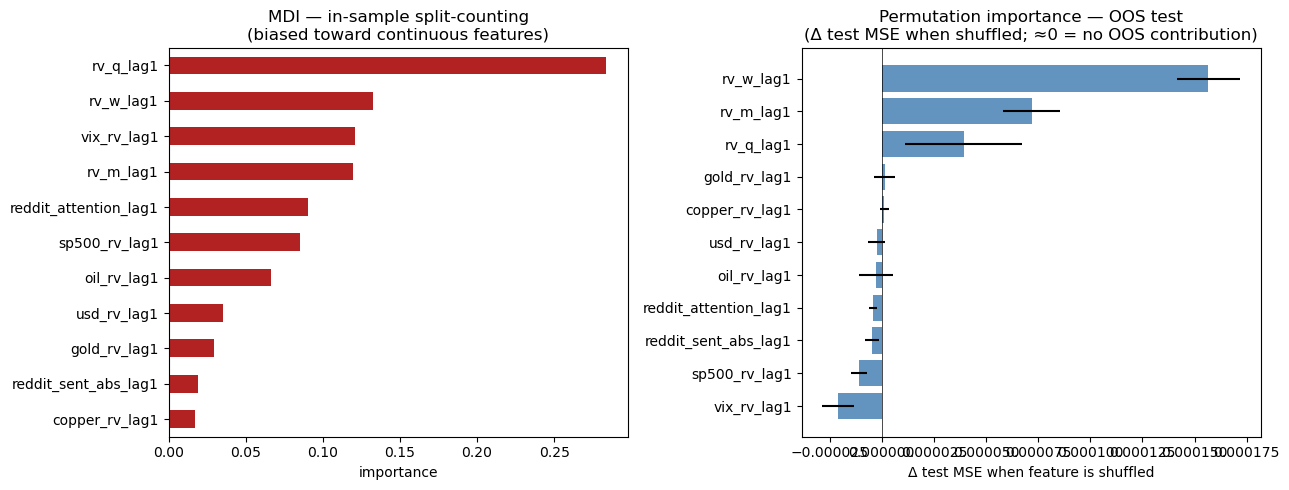

MDI (in-sample) ranking:
rv_q_lag1                0.2836
rv_w_lag1                0.1324
vix_rv_lag1              0.1211
rv_m_lag1                0.1195
reddit_attention_lag1    0.0905
sp500_rv_lag1            0.0855
oil_rv_lag1              0.0665
usd_rv_lag1              0.0356
gold_rv_lag1             0.0294
reddit_sent_abs_lag1     0.0190
copper_rv_lag1           0.0169

Permutation importance (OOS test) ranking:
rv_w_lag1                0.000157
rv_m_lag1                0.000072
rv_q_lag1                0.000039
gold_rv_lag1             0.000001
copper_rv_lag1           0.000001
usd_rv_lag1             -0.000002
oil_rv_lag1             -0.000003
reddit_attention_lag1   -0.000004
reddit_sent_abs_lag1    -0.000005
sp500_rv_lag1           -0.000011
vix_rv_lag1             -0.000021


In [17]:
from sklearn.inspection import permutation_importance

# Re-fit the combined sentiment rung canonically on sent_trval (single fit on
# train+val) and compute two importance measures side-by-side on the test set:
#   (a) MDI -- in-sample split-counting; biased toward continuous features with
#       many candidate split thresholds (Strobl et al. 2007).
#   (b) Permutation importance (Breiman 2001) -- shuffles each test-set feature
#       and measures the rise in test MSE; a feature with perm-importance ≈ 0
#       contributes nothing to OOS predictions even if MDI gives it a non-zero
#       score.
# The contrast between the two plots is the diagnostic: features where MDI is
# meaningfully positive but permutation importance is ≈ 0 are split-on by the
# trees in-sample but don't help OOS. Sentiment features are expected to fall in
# this category for our small linear effect.
combined_feats = FEATS_HAR + FEATS_EXOG + FEATS_SENT_ATTN + FEATS_SENT_INT
sent_trval     = abl[abl['split'] != 'test']

combined_best = tune_rf(sent_train[combined_feats], sent_train['target'],
                        val_df[combined_feats],     val_df['target'])
model = RandomForestRegressor(random_state=SEED, **combined_best).fit(
            sent_trval[combined_feats], sent_trval['target'])

mdi  = pd.Series(model.feature_importances_, index=combined_feats)
perm = permutation_importance(model, sent_test[combined_feats], y_st,
                              n_repeats=20, random_state=SEED,
                              scoring='neg_mean_squared_error')
perm_mean = pd.Series(perm.importances_mean, index=combined_feats)
perm_std  = pd.Series(perm.importances_std,  index=combined_feats)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
mdi.sort_values().plot.barh(ax=ax[0], color='firebrick')
ax[0].set_title('MDI — in-sample split-counting\n(biased toward continuous features)')
ax[0].set_xlabel('importance')

ord_perm = perm_mean.sort_values().index
ax[1].barh(ord_perm, perm_mean[ord_perm], xerr=perm_std[ord_perm],
           color='steelblue', alpha=0.85)
ax[1].axvline(0, color='black', lw=0.5)
ax[1].set_title('Permutation importance — OOS test\n(Δ test MSE when shuffled; ≈0 = no OOS contribution)')
ax[1].set_xlabel('Δ test MSE when feature is shuffled')

plt.tight_layout(); plt.show()

print('MDI (in-sample) ranking:')
print(mdi.sort_values(ascending=False).round(4).to_string())
print('\nPermutation importance (OOS test) ranking:')
print(perm_mean.sort_values(ascending=False).round(6).to_string())

## 8. Save outputs

- `metrics_rf_volatility.csv` — Random Forest headline metrics
- `pred_rf_volatility.csv` — test-set predictions, consumed by `evaluation.ipynb`
- `metrics_rf_sentiment_volatility.csv` — the §6 sentiment-ablation table (saved above)

In [18]:
pd.DataFrame(results).to_csv('../../data/processed/metrics_rf_volatility.csv', index=False)

pred_rf = pd.DataFrame({'actual': y_test, 'prev': prev_test, 'rf': rf_pred}, index=test_df.index)
pred_rf.to_csv('../../data/processed/pred_rf_volatility.csv', index_label='Date')
print('Saved metrics_rf_volatility.csv + pred_rf_volatility.csv')
pd.DataFrame(results).round(5)


Saved metrics_rf_volatility.csv + pred_rf_volatility.csv


,model,rmse,mae,r2,dca
0,RF (HAR+EXOG),0.03326,0.01742,0.23808,0.68391
